# <center> Проект: Прогнозирование рейтинга отеля на Booking
   

### <center> ВАРИАНТ 1: Базовый (только числовые признаки)

Признаки:  

hotel_address — адрес отеля;

additional_number_of_scoring — есть также некоторые гости, которые просто поставили оценку сервису, но не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки.

review_date — дата, когда рецензент разместил соответствующий отзыв;

average_score — средний балл отеля, рассчитанный на основе последнего комментария за последний год;

hotel_name — название отеля;

reviewer_nationality — страна рецензента;

negative_review — отрицательный отзыв, который рецензент дал отелю;

review_total_negative_word_counts — общее количество слов в отрицательном отзыв;

total_number_of_reviews — общее количество действительных отзывов об отеле;

positive_review — положительный отзыв, который рецензент дал отелю;

review_total_positive_word_counts — общее количество слов в положительном отзыве.

total_number_of_reviews_reviewer_has_given — количество отзывов, которые рецензенты дали в прошлом;

reviewer_score — оценка, которую рецензент поставил отелю на основе своего опыта;

tags — теги, которые рецензент дал отелю;

days_since_review — количество дней между датой проверки и датой очистки;

lat — географическая широта отеля;

lng — географическая долгота отеля.

In [1]:
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Чтение данных из файла
hotels = pd.read_csv('hotels.csv')
# Вывод информации о датасете
print("Информация о таблице:")
hotels.head()

Информация о таблице:


,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,9/22/2015,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,Friendly staff quiet comfortable room spotles...,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,48.888697,2.394540
4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,3/5/2016,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,The staff was very friendly and helpful Break...,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,52.385601,4.847060


In [3]:
# Вывод информации о столбцах
print(hotels.info())

<class 'pandas.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  str    
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  str    
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  str    
 5   reviewer_nationality                        386803 non-null  str    
 6   negative_review                             386803 non-null  str    
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  str    
 10  review_

In [4]:
# Для начала разделим признаки по типу, перечислим их:
# непрерывные признаки
num_cols = ['additional_number_of_scoring', 'review_total_negative_word_counts', 'total_number_of_reviews', 
            'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'reviewer_score']

# категориальные признаки
cat_cols = ['average_score', 'review_date', 'lat', 'lng']

In [5]:
# Сколько уникальных названий отелей представлено в наборе данных?
print(f"Количество уникальных названий отелей: {hotels['hotel_name'].nunique()}")

Количество уникальных названий отелей: 1492


In [6]:
# Когда был оставлен самый свежий отзыв? Введите ответ в формате yyyy-mm-dd. (месяц/число/год)
# Преобразуем признак в формат даты
hotels['review_date'] = pd.to_datetime(hotels['review_date'], format='%m/%d/%Y')

print(f"Самый свежий отзыв был оставлен : {hotels['review_date'].sort_values().iloc[-1]}")

# Когда был оставлен самый первый отзыв? Введите ответ в формате yyyy-mm-dd.
print(f"Самый первый отзыв был оставлен : {hotels['review_date'].sort_values().iloc[0]}")

Самый свежий отзыв был оставлен : 2017-08-03 00:00:00
Самый первый отзыв был оставлен : 2015-08-04 00:00:00


In [7]:
# Сколько уникальных тегов представлено в наборе данных?
# Создаем функцию преобразования строки в список
def split_str(tag):

    """ 
    Преобразует строковое представление списка тегов в список строк

    Этапы обработки:
        1. Удаляет квадратные скобки и кавычки по краям строки.
        2. Разбивает строку по запятым.
        3. Очищает каждый тег от лишних пробелов.
    
        Args:
            tag (str): Строка с тегами вида "['Leisure trip', 'Couple']"
    
        Returns:
            list: Список очищенных тегов

    """

    # Задаем пустую строку
    str_tags = ""
    # Задаем пустой список
    lst_tags = []

    # Проходим по каждому символу строки, удаляя лишние символы
    for row in tag:
        str_tags += row.strip('[]').replace("'", "")

    # Разделяем строку по запятым и добавляем теги в список
    for word in str_tags.split(','):
        lst_tags.append(word.strip())

    return lst_tags

# Преобразование колонки 'tags' из строки в список
hotels['tags'] = hotels['tags'].apply(split_str)

# Альтернативный метод:
# Метод explode() создает отдельную строку для каждого тега, что увеличивает
# использование памяти. Это может быть полезно для детального анализа, но не
# рекомендуется для простого подсчета уникальных значений.
# clean_tags = hotels.explode('tags')
# clean_tags['tags'].value_counts()

# Оптимальный метод:
# Использование множества (set) позволяет подсчитать количество уникальных тегов
# без создания дополнительных копий данных, что экономит память.
# Задаем переменную множества
set_tags = set()
# Проходим по каждому списку тегов в колонке
for lst in hotels['tags']:
    # Проходим по каждому тегу внутри списка
    for tag in lst:
        # Добавляем тег в множество (дубликаты автоматически игнорируются)
        set_tags.add(tag)
# Выводим общее количество уникальных тегов
print(f"Количество уникальных тегов: {len(set_tags)}")

Количество уникальных тегов: 2368


In [8]:
# Какой тег представлен в наибольшем числе отзывов?
clean_tags = hotels.explode('tags')
clean_tags['tags'].value_counts()

tags
Leisure trip                                      313593
Submitted from a mobile device                    230778
Couple                                            189212
Stayed 1 night                                    145373
Stayed 2 nights                                   100263
                                                   ...  
Special Offer Double or Twin Room with Parking         1
Westminster Suite with King Bed                        1
Quadruple Room 2 Adults 2 Children                     1
Art Deco Room Terrace                                  1
Executive Double Room Non Smoking                      1
Name: count, Length: 2368, dtype: int64

In [9]:
# Из тегов выясните, на сколько ночей чаще всего останавливаются путешественники в отелях.
display(clean_tags['tags'].value_counts())
# Stayed 1 night 145373

tags
Leisure trip                                      313593
Submitted from a mobile device                    230778
Couple                                            189212
Stayed 1 night                                    145373
Stayed 2 nights                                   100263
                                                   ...  
Special Offer Double or Twin Room with Parking         1
Westminster Suite with King Bed                        1
Quadruple Room 2 Adults 2 Children                     1
Art Deco Room Terrace                                  1
Executive Double Room Non Smoking                      1
Name: count, Length: 2368, dtype: int64

In [10]:
# Удаляем все строковые столбцы
object_columns = [s for s in hotels.columns if hotels[s].dtypes not in ['int64', 'float64']]
hotels.drop(object_columns, axis=1, inplace=True)

In [11]:
# Заполняем пропуски
hotels = hotels.fillna(0)

In [12]:
# Проверяем долю дубликатов
display(hotels.duplicated().mean()*100)
# Очищаем датасет от дубликатов
hotels_clean = hotels.drop_duplicates()
# Выводим краткую информацию о получившемся датасете
hotels_clean.info()

np.float64(2.350033479574874)

<class 'pandas.DataFrame'>
Index: 377713 entries, 0 to 386802
Data columns (total 9 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                377713 non-null  int64  
 1   average_score                               377713 non-null  float64
 2   review_total_negative_word_counts           377713 non-null  int64  
 3   total_number_of_reviews                     377713 non-null  int64  
 4   review_total_positive_word_counts           377713 non-null  int64  
 5   total_number_of_reviews_reviewer_has_given  377713 non-null  int64  
 6   reviewer_score                              377713 non-null  float64
 7   lat                                         377713 non-null  float64
 8   lng                                         377713 non-null  float64
dtypes: float64(4), int64(5)
memory usage: 28.8 MB


In [13]:
# Статистическая информация признаков
hotels_clean.describe()

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,lat,lng
count,377713.000000,377713.000000,377713.000000,377713.000000,377713.000000,377713.000000,377713.000000,377713.000000,377713.000000
mean,490.041902,8.393536,18.930789,2717.375587,17.928067,7.297623,8.370094,49.100735,2.839115
std,493.389226,0.547694,29.922993,2300.979343,21.911194,11.142026,1.638681,5.253981,4.593273
min,1.000000,5.200000,0.000000,43.000000,0.000000,1.000000,2.500000,0.000000,-0.369758
25%,167.000000,8.100000,2.000000,1146.000000,5.000000,1.000000,7.500000,48.211084,-0.143372
50%,337.000000,8.400000,9.000000,2113.000000,11.000000,3.000000,8.800000,51.499393,0.019886
75%,639.000000,8.800000,24.000000,3609.000000,23.000000,9.000000,9.600000,51.516288,4.834443
max,2682.000000,9.800000,408.000000,16670.000000,395.000000,355.000000,10.000000,52.400181,16.429233


#### Вывод:
В данных присутствуют признаки с выбросами: 
- total_number_of_reviews (максимум 16 670 при среднем 2 700)
- total_number_of_reviews_reviewer_has_given (максимум 355 при среднем 7). 

Это может указывать на наличие отелей-лидеров по популярности и сверхактивных рецензентов. 
Влияние этих выбросов на модель RandomForest не критично, но в дальнейшем их можно логарифмировать для улучшения интерпретируемости.

In [14]:
# Разделяем на признаки (X) и целевую переменную (y)
X = hotels_clean.drop(['reviewer_score'], axis = 1)  
y = hotels_clean['reviewer_score'] 

In [15]:
# Импортируем необходимые библиотеки
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

# Разбиваем на обучающую и тестовую выборки (75% / 25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Отбираем 8 лучших признаков с помощью SelectKBest
selector = SelectKBest(score_func=f_regression, k=8)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [16]:

# Сохраняем и выводим значимость признаков
feature_importance = pd.DataFrame({
    'Признак': X.columns,
    'F-статистика': selector.scores_
}).sort_values('F-статистика', ascending=False)

# Выводим значимость признаков
print(feature_importance)

                                      Признак  F-статистика
2           review_total_negative_word_counts  47030.644943
1                               average_score  42624.230392
4           review_total_positive_word_counts  15276.375895
3                     total_number_of_reviews   1873.531877
0                additional_number_of_scoring   1515.073639
7                                         lng    455.807831
6                                         lat    191.112007
5  total_number_of_reviews_reviewer_has_given     34.843833


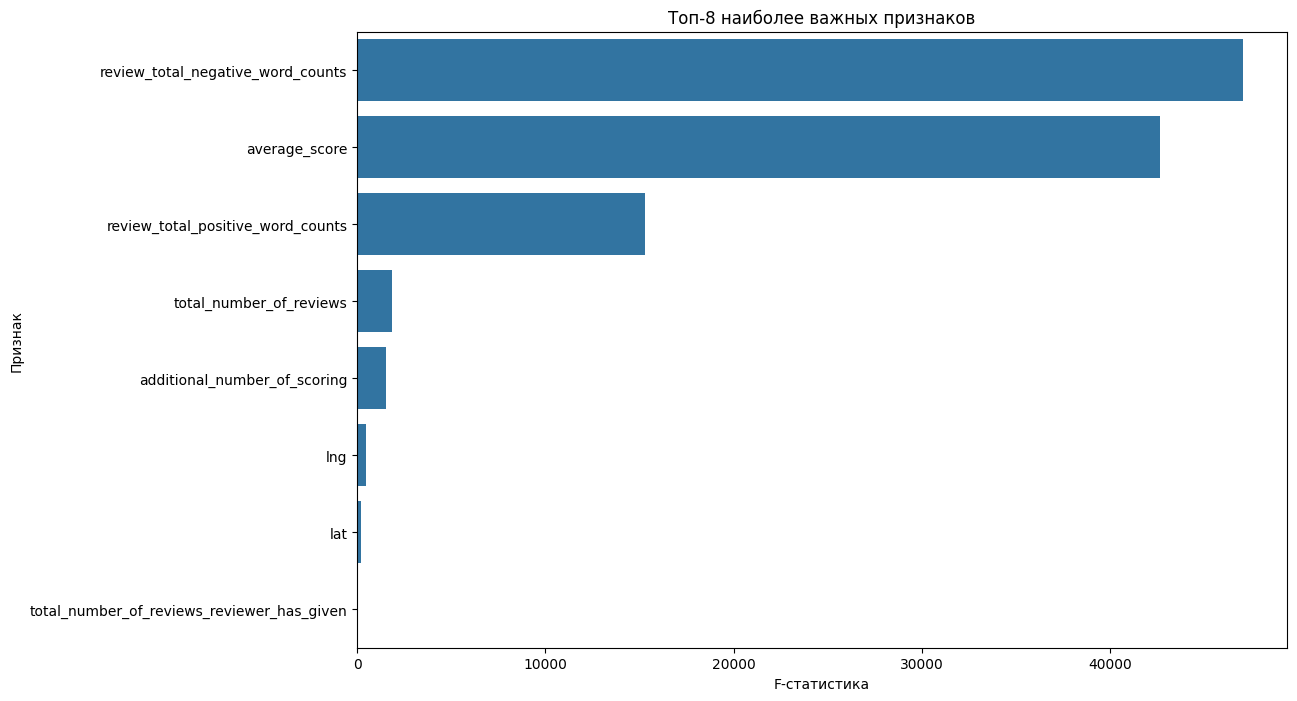

In [17]:
# Визуализируем топ-8 признаков
plt.figure(figsize=(12, 8))

# Сортируем и строим
top_features = feature_importance.head(8)
sns.barplot(data=top_features, y='Признак', x='F-статистика')

# Задаем название диаграмме и осям
plt.title('Топ-8 наиболее важных признаков')
plt.xlabel('F-статистика')
plt.ylabel('Признак')

# Выводим диаграмму
plt.show()

In [18]:
# Создаём и обучаем модель на отобранных признаках
regr = RandomForestRegressor(n_estimators=100)
regr.fit(X_train_selected, y_train)

# Предсказываем и оцениваем качество
y_pred = regr.predict(X_test_selected)
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.14350535880685356


## Общий вывод:

Первый вариант показал, что использование только числовых признаков без учёта текстовой информации (даты, отзывы, теги) даёт базовый уровень качества.

MAPE = 14.35% - показатель даже ухудшился по сравнению с базовым показателем (14.12%)

Удаление строковых признаков, скорее всего, привело к потере полезной информации, поэтому во втором варианте планируется извлечение новых признаков из даты, отзывов и тегов.